# HoopStats Analysis Notebook

This notebook provides comprehensive analysis of basketball tracking data:
- Load and explore detection and tracking data
- Analyze player trajectories and zones
- Compute statistics on player positions and movements
- Visualize results on court and bird's eye view

## 1. Setup and Imports

In [1]:
import os
import sys
import pathlib
import pickle
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import defaultdict
from time import time
import importlib

# Import project modules
from courtvisionlib.functions import *
from cav.objects import BoundingBox, Object, ObjectType
import project_config as config

importlib.reload(config)
%matplotlib inline

print("All imports successful!")

All imports successful!


## 2. Load Configuration and Parameters

In [2]:
# Load parameters
with open('params.json', 'r') as f:
    params = json.load(f)

print("Parameters loaded:")
for key, value in params.items():
    print(f"  {key}: {value}")

# Extract key parameters
video_shape = tuple(params['videoShape'])
bird_eye_shape = tuple(params['birdEyeViewShape'])
camera_points = np.array(params['cameraPoints'], dtype='float32')
bird_eye_points = np.array(params['birdEyePoints'], dtype='float32')

print(f"\nVideo shape: {video_shape}")
print(f"Bird eye view shape: {bird_eye_shape}")

Parameters loaded:
  videoShape: [3840, 2160]
  birdEyeViewShape: [612, 433]
  cameraPoints: [[973, 932], [2841, 936], [383, 1316], [3440, 1311]]
  birdEyePoints: [[88, 91], [523, 91], [87, 333], [523, 334]]
  lanes_mask: images/mask_org.png

Video shape: (3840, 2160)
Bird eye view shape: (612, 433)


## 4. Visualization Functions

In [7]:
def visualize_detections_on_frame(frame, boxes, scores, classes,
                                   confidence_threshold=0.5,
                                   figsize=(15, 10)):
    """
    Visualizes detections on a frame.

    Arguments:
        frame: Input frame (BGR)
        boxes: Detection boxes
        scores: Detection confidence scores
        classes: Detection classes
        confidence_threshold: Minimum confidence to display
        figsize: Figure size
    """
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(frame_rgb)

    # Filter by confidence
    for i, (box, score) in enumerate(zip(boxes, scores)):
        if score >= confidence_threshold:
            ymin, xmin, ymax, xmax = box

            # Convert normalized coordinates to pixel coordinates
            ymin = int(ymin * frame.shape[0])
            ymax = int(ymax * frame.shape[0])
            xmin = int(xmin * frame.shape[1])
            xmax = int(xmax * frame.shape[1])

            # Draw rectangle
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                    linewidth=2, edgecolor='g', facecolor='none')
            ax.add_patch(rect)

            # Add label
            ax.text(xmin, ymin - 5, f'{score:.2f}',
                   color='white', fontsize=8,
                   bbox=dict(facecolor='green', alpha=0.5))

    plt.title('Detections')
    plt.axis('off')
    plt.tight_layout()
    return fig, ax

print("Visualization functions defined.")

Visualization functions defined.


## 5. Load and Display Sample Frame

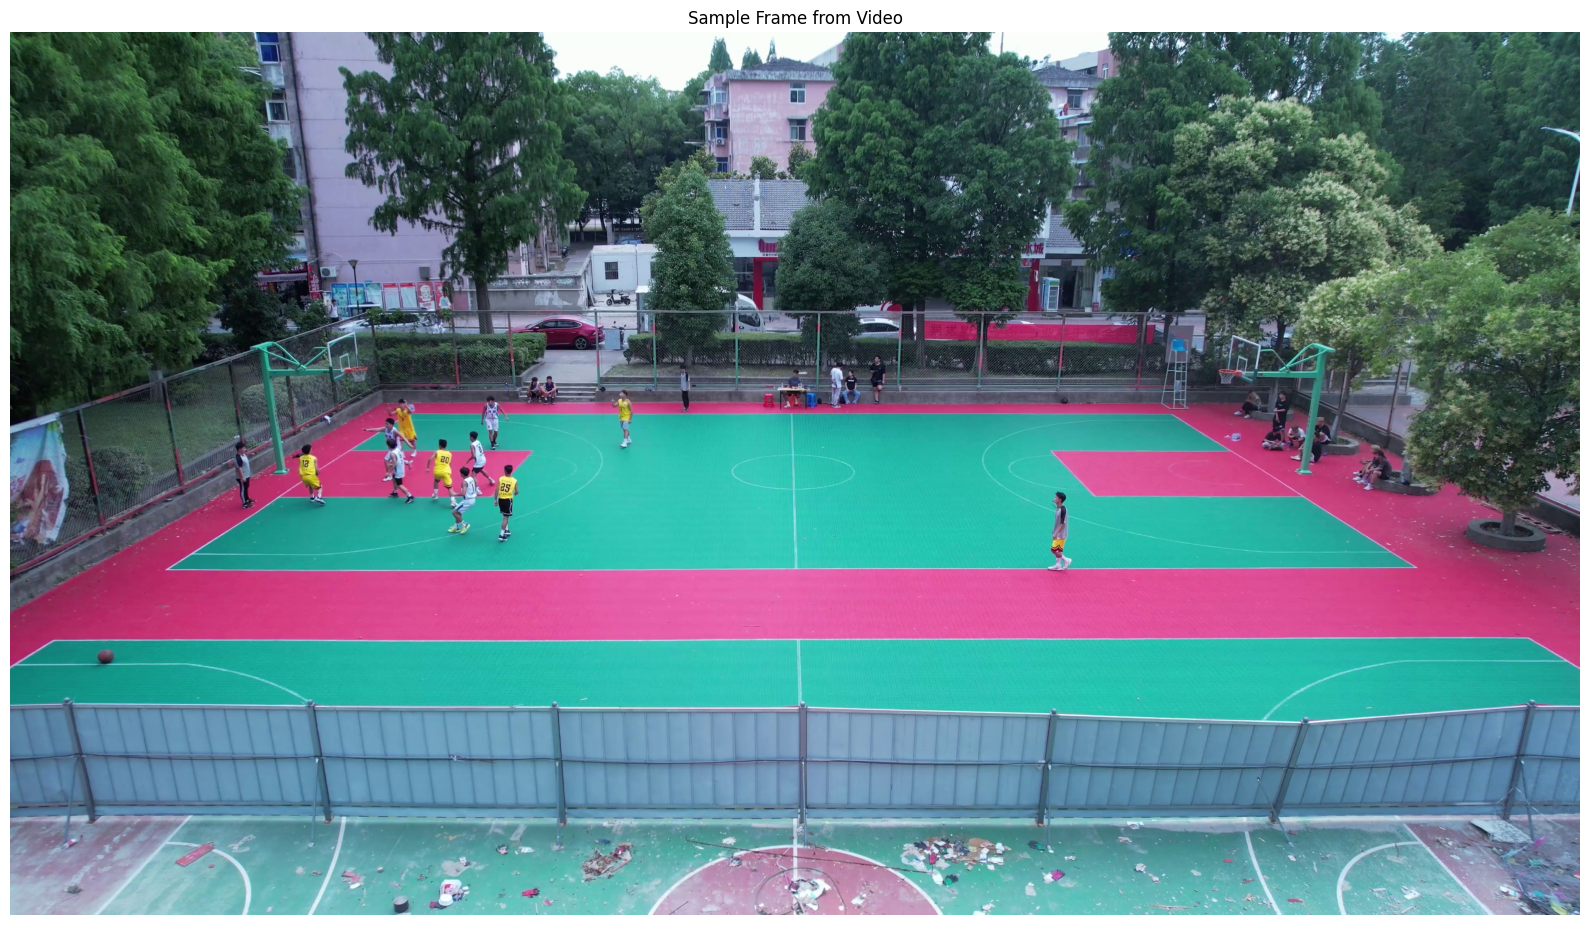

Frame shape: (2160, 3840, 3)


In [8]:
# Load a sample frame
frame_image_path = './images/frame_view1.jpg'
if os.path.exists(frame_image_path):
    sample_frame_img = cv2.imread(frame_image_path)
    sample_frame_rgb = cv2.cvtColor(sample_frame_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 10))
    plt.imshow(sample_frame_rgb)
    plt.title('Sample Frame from Video')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Frame shape: {sample_frame_img.shape}")
else:
    print(f"Sample frame not found at {frame_image_path}")

## 6. Bird's Eye View Analysis

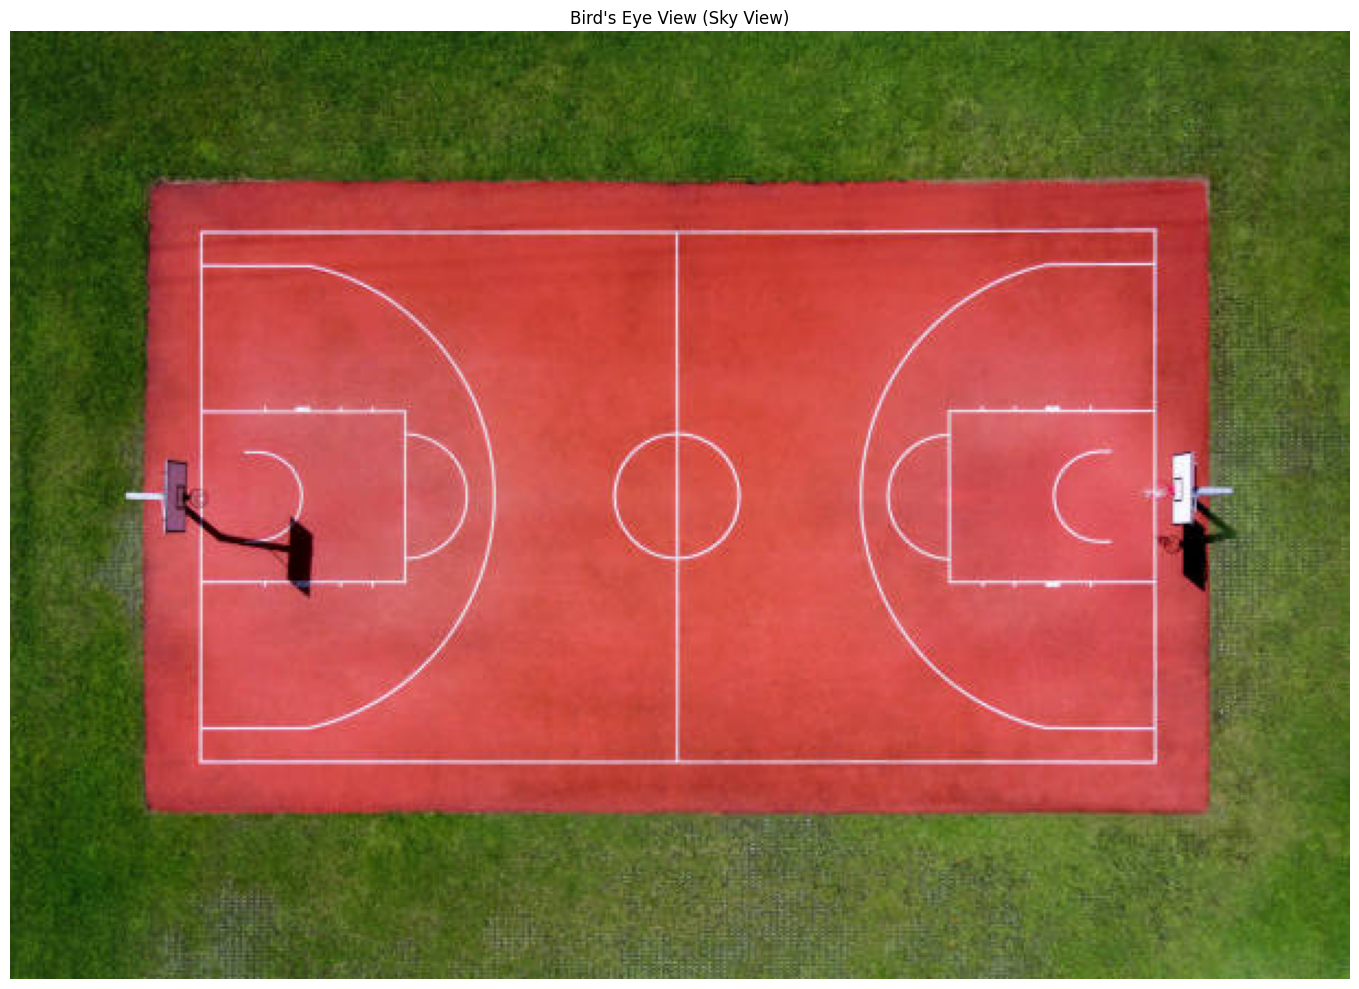

Bird's eye view shape: (433, 612, 3)


In [9]:
# Load bird's eye view image
sky_view_path = './images/Sky View.jpg'
if os.path.exists(sky_view_path):
    sky_view_img = cv2.imread(sky_view_path)
    sky_view_rgb = cv2.cvtColor(sky_view_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 10))
    plt.imshow(sky_view_rgb)
    plt.title('Bird\'s Eye View (Sky View)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Bird's eye view shape: {sky_view_img.shape}")
else:
    print(f"Sky view not found at {sky_view_path}")

## 7. Perspective Transform Analysis

In [10]:
# Calculate perspective transform matrices
M = cv2.getPerspectiveTransform(camera_points, bird_eye_points)
M_inv = cv2.getPerspectiveTransform(bird_eye_points, camera_points)

print("Perspective Transform Matrices calculated successfully.")

Perspective Transform Matrices calculated successfully.


## 8. Load Tracking Data

In [12]:
def load_tracking_data(csv_path=None):
    """
    Load tracking data from CSV or create sample DataFrame.

    Expected columns: frame, zone, playerId, x, y, birdEyeX, birdEyeY,
                     timestamp, objectType, teamId, possession
    """
    if csv_path and os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f"Loaded tracking data from {csv_path}")
    else:
        # Create empty DataFrame with expected columns
        df = pd.DataFrame(columns=[
            'frame', 'zone', 'playerId', 'x', 'y', 'birdEyeX', 'birdEyeY',
            'timestamp', 'objectType', 'teamId', 'possession'
        ])
        print("Created empty tracking DataFrame. Load your CSV with: df = load_tracking_data('path/to/data.csv')")

    print(f"\nDataFrame shape: {df.shape}")
    if not df.empty:
        print(f"\nDataFrame columns: {list(df.columns)}")
        print(f"\nFirst few rows:")
        print(df.head())
        print(f"\nData types:")
        print(df.dtypes)

    return df
csv_path = os.path.join(config.DATA_PATH, 'zones_detections.csv')
# Load or create tracking data
tracking_df = load_tracking_data(csv_path)
# To load your own data, uncomment and modify:
# tracking_df = load_tracking_data('path/to/your/tracking_data.csv')

Loaded tracking data from HoopStats_assets/data/zones_detections.csv

DataFrame shape: (779, 11)

DataFrame columns: ['frame', 'zone', 'player id', 'x', 'y', 'birdX', 'birdY', 'time', 'objtype', 'team', 'possession']

First few rows:
   frame  zone  player id     x     y       birdX       birdY      time  \
0     14     0          8  2490  1328  382.891785  339.666931  0.583917   
1     14     3         12  1076  1262  176.805115  311.556030  0.583917   
2     14     3         13  1291  1222  204.744339  293.600616  0.583917   
3     14     3         14  1485  1033  218.284409  179.966827  0.583917   
4     14     4         16   962  1058  121.850479  198.640381  0.583917   

   objtype  team  possession  
0        1     0           0  
1        1     1           0  
2        1     2           0  
3        1     2           0  
4        1     2           0  

Data types:
frame           int64
zone            int64
player id       int64
x               int64
y               int64
birdX 

## 9. Movement and Speed Analytics

In [21]:
import numpy as np
import pandas as pd

def compute_speed_metrics_bird(df, max_allowed_speed_mps=12.0):
    """
    Compute speed and movement metrics for each player using bird coordinates.
    Filters out unrealistic speeds (> max_allowed_speed_mps).
    
    Court dimensions: 28.65m × 15.24m
    Bird coordinates: x: 87-522 (length), y: 91-332 (width)
    
    Args:
        df: DataFrame with tracking data
        max_allowed_speed_mps: Maximum realistic speed in m/s (default 12.0)
    """
    if df.empty or 'time' not in df.columns:
        print("Cannot compute speed metrics - empty DataFrame or missing timestamp")
        return pd.DataFrame()

    # Court dimensions in meters
    COURT_LENGTH_M = 28.65
    COURT_WIDTH_M = 15.24
    
    # Bird coordinate boundaries
    BIRD_X_MIN = 87
    BIRD_X_MAX = 522
    BIRD_Y_MIN = 91
    BIRD_Y_MAX = 332
    
    # Calculate pixel-to-meter conversion factors
    PIXELS_PER_METER_X = (BIRD_X_MAX - BIRD_X_MIN) / COURT_LENGTH_M
    PIXELS_PER_METER_Y = (BIRD_Y_MAX - BIRD_Y_MIN) / COURT_WIDTH_M
    
    # Use average for conversion
    PIXELS_PER_METER = (PIXELS_PER_METER_X + PIXELS_PER_METER_Y) / 2
    METERS_PER_PIXEL = 1 / PIXELS_PER_METER
    
    print(f"Pixel to meter conversion: {METERS_PER_PIXEL:.4f} meters per pixel")
    print(f"Court dimensions in pixels: {BIRD_X_MAX-BIRD_X_MIN:.0f} × {BIRD_Y_MAX-BIRD_Y_MIN:.0f}")
    print(f"Maximum allowed speed: {max_allowed_speed_mps} m/s")
    
    metrics = []
    
    # Filter out ball and refree
    excluded_players = [8, 25, 28, 32]
    
    # Get unique player IDs
    all_player_ids = df['player id'].unique()
    valid_player_ids = [pid for pid in all_player_ids if pid not in excluded_players]
    
    print(f"Processing {len(valid_player_ids)} players (excluding {excluded_players})")
    
    # Track speed filtering statistics
    total_speeds_calculated = 0
    filtered_speeds = 0
    
    # Process each player
    for player_id in valid_player_ids:
        # Get all detections for this player
        player_data = df[df['player id'] == player_id].copy()
        
        total_detections = len(player_data)  # Store this for later use
        
        if total_detections < 2:
            print(f"Player {player_id}: Insufficient data ({total_detections} detections)")
            continue
        
        # Sort by time to get sequential detections
        player_data = player_data.sort_values('time').reset_index(drop=True)
        
        # Extract bird coordinates and time
        bird_x = player_data['birdX'].values
        bird_y = player_data['birdY'].values
        times = player_data['time'].values
        
        # Lists to store calculations
        speeds_mps = []  # meters per second
        accelerations_mps2 = []  # meters per second squared
        valid_time_diffs = []  # Store time differences for valid measurements
        distances_m = []  # Store distances for valid measurements
        
        # Process each pair of consecutive detections
        for i in range(total_detections - 1):
            # Get current and next detection
            x1, y1 = bird_x[i], bird_y[i]
            x2, y2 = bird_x[i+1], bird_y[i+1]
            t1, t2 = times[i], times[i+1]
            
            # Calculate time difference in seconds
            dt = t2 - t1
            
            # Skip if time difference is too small or negative
            if dt <= 0.001:  # Skip if less than 1ms
                continue
            
            # Calculate distance in pixels
            dx_pixels = x2 - x1
            dy_pixels = y2 - y1
            distance_pixels = np.sqrt(dx_pixels**2 + dy_pixels**2)
            
            # Convert distance to meters
            distance_meters = distance_pixels * METERS_PER_PIXEL
            
            # Calculate speed (m/s)
            speed_mps = distance_meters / dt
            
            # FILTER: Skip unrealistic speeds
            total_speeds_calculated += 1
            
            if speed_mps > max_allowed_speed_mps:
                filtered_speeds += 1
                # Skip this speed measurement (but continue with next pair)
                continue
            
            # Also filter by minimum time interval to avoid noisy measurements
            # For very short time intervals, small positional errors cause huge speeds
            min_time_threshold = 0.04  # 40ms minimum
            if dt < min_time_threshold and speed_mps > 8.0:
                # This is likely a tracking error - skip it
                filtered_speeds += 1
                continue
            
            # Store valid speed
            speeds_mps.append(speed_mps)
            valid_time_diffs.append(dt)
            distances_m.append(distance_meters)
        
        # Skip if no valid speeds calculated
        if not speeds_mps:
            print(f"Player {player_id}: No valid speed measurements after filtering")
            continue
        
        # Convert to numpy arrays for statistics
        speeds_mps = np.array(speeds_mps)
        valid_time_diffs = np.array(valid_time_diffs)
        distances_m = np.array(distances_m)
        
        # Calculate accelerations from valid speeds
        if len(speeds_mps) >= 2:
            for i in range(1, len(speeds_mps)):
                speed_change = speeds_mps[i] - speeds_mps[i-1]
                # Use average time for this and previous interval
                avg_dt = (valid_time_diffs[i] + valid_time_diffs[i-1]) / 2
                if avg_dt > 0:
                    acceleration = speed_change / avg_dt
                    # Filter unrealistic accelerations (> 10 m/s²)
                    if abs(acceleration) <= 10.0:  # Maximum human acceleration
                        accelerations_mps2.append(acceleration)
        
        # Calculate total valid distance in meters
        total_distance_meters = np.sum(distances_m)
        
        # Calculate time covered by valid measurements
        valid_time_interval = np.sum(valid_time_diffs)
        
        # Calculate summary metrics
        player_metrics = {
            'player id': player_id,
            'team': player_data['team'].iloc[0] if 'team' in player_data.columns else None,
            'objtype': player_data['objtype'].iloc[0] if 'objtype' in player_data.columns else None,
            'total_detections': total_detections,
            'valid_speed_measurements': len(speeds_mps),
            'valid_time_seconds': valid_time_interval,
            'total_distance_meters': total_distance_meters,
            'avg_speed_mps': np.mean(speeds_mps) if len(speeds_mps) > 0 else 0,
            'max_speed_mps': np.max(speeds_mps) if len(speeds_mps) > 0 else 0,
            'min_speed_mps': np.min(speeds_mps) if len(speeds_mps) > 0 else 0,
            'std_speed_mps': np.std(speeds_mps) if len(speeds_mps) > 0 else 0,
            'speed_95th_percentile': np.percentile(speeds_mps, 95) if len(speeds_mps) > 0 else 0,
            'avg_acceleration_mps2': np.mean(accelerations_mps2) if len(accelerations_mps2) > 0 else 0,
            'max_acceleration_mps2': np.max(accelerations_mps2) if len(accelerations_mps2) > 0 else 0,
            'min_acceleration_mps2': np.min(accelerations_mps2) if len(accelerations_mps2) > 0 else 0,
            'acceleration_measurements': len(accelerations_mps2),
            'avg_time_interval': np.mean(valid_time_diffs) if len(valid_time_diffs) > 0 else 0,
        }
        
        metrics.append(player_metrics)
        
        # Print progress for each player 
        print(f"Player {player_id}: {len(speeds_mps)}/{total_detections-1} valid speeds, "
              f"Max: {player_metrics['max_speed_mps']:.2f} m/s, "
              f"Avg: {player_metrics['avg_speed_mps']:.2f} m/s")
    
    # Print filtering statistics
    print(f"\nFiltering Statistics:")
    print(f"Total speed calculations: {total_speeds_calculated}")
    print(f"Filtered speeds (> {max_allowed_speed_mps} m/s or noisy): {filtered_speeds}")
    if total_speeds_calculated > 0:
        print(f"Filtering rate: {filtered_speeds/total_speeds_calculated*100:.1f}%")
    else:
        print("No speed calculations were made")
    
    # Create results DataFrame
    if metrics:
        speed_df = pd.DataFrame(metrics)
        
        # Sort by max speed (descending)
        speed_df = speed_df.sort_values('max_speed_mps', ascending=False).reset_index(drop=True)
        
        return speed_df
    else:
        print("No metrics computed for any player")
        return pd.DataFrame()


# Additional function to analyze speed distribution
def analyze_speed_distribution(df, max_speed_threshold=12.0):
    """
    Analyze speed distribution to help set appropriate thresholds.
    """
    # Court dimensions for conversion
    COURT_LENGTH_M = 28.65
    COURT_WIDTH_M = 15.24
    BIRD_X_MIN = 87
    BIRD_X_MAX = 522
    BIRD_Y_MIN = 91
    BIRD_Y_MAX = 332
    
    PIXELS_PER_METER_X = (BIRD_X_MAX - BIRD_X_MIN) / COURT_LENGTH_M
    PIXELS_PER_METER_Y = (BIRD_Y_MAX - BIRD_Y_MIN) / COURT_WIDTH_M
    PIXELS_PER_METER = (PIXELS_PER_METER_X + PIXELS_PER_METER_Y) / 2
    METERS_PER_PIXEL = 1 / PIXELS_PER_METER
    
    all_speeds = []
    
    for player_id in df['player id'].unique():
        player_data = df[df['player id'] == player_id].sort_values('time')
        
        total_detections = len(player_data)
        
        if total_detections < 2:
            continue
            
        bird_x = player_data['birdX'].values
        bird_y = player_data['birdY'].values
        times = player_data['time'].values
        
        for i in range(total_detections - 1):
            dt = times[i+1] - times[i]
            if dt <= 0:
                continue
                
            dx_pixels = bird_x[i+1] - bird_x[i]
            dy_pixels = bird_y[i+1] - bird_y[i]
            distance_pixels = np.sqrt(dx_pixels**2 + dy_pixels**2)
            distance_meters = distance_pixels * METERS_PER_PIXEL
            speed_mps = distance_meters / dt
            
            all_speeds.append(speed_mps)
    
    all_speeds = np.array(all_speeds)
    
    if len(all_speeds) == 0:
        print("No speed measurements found in the data")
        return
    
    print("\n" + "="*80)
    print("SPEED DISTRIBUTION ANALYSIS")
    print("="*80)
    print(f"Total speed measurements: {len(all_speeds)}")
    
    above_threshold = np.sum(all_speeds > max_speed_threshold)
    print(f"Speeds above {max_speed_threshold} m/s: {above_threshold} "
          f"({above_threshold/len(all_speeds)*100:.1f}%)")
    
    
    print(f"\nStatistics:")
    print(f"  Mean: {np.mean(all_speeds):.2f} m/s")
    print(f"  Median: {np.median(all_speeds):.2f} m/s")
    print(f"  Max: {np.max(all_speeds):.2f} m/s")
    print(f"  Min: {np.min(all_speeds):.2f} m/s")
    print(f"  Std: {np.std(all_speeds):.2f} m/s")


# Execute the analysis
if not tracking_df.empty:
    # First analyze the speed distribution
    analyze_speed_distribution(tracking_df, max_speed_threshold=12.0)
    
    print("\n" + "="*80)
    print("FILTERED SPEED METRICS ")
    print("="*80)
    
    # Now compute metrics with filtering
    # You can adjust the max_allowed_speed_mps based on the distribution analysis
    speed_metrics = compute_speed_metrics_bird(tracking_df, max_allowed_speed_mps=12.0)
    
    if not speed_metrics.empty:
        print(f"\nMetrics for {len(speed_metrics)} players:")
        print("\nTop 10 fastest players:")
        print(speed_metrics[['player id', 'team', 'max_speed_mps']].head(10).to_string())
        
        # Summary statistics
        print("\n" + "="*80)
        print("OVERALL STATISTICS (FILTERED):")
        print("="*80)
        print(f"Total players analyzed: {len(speed_metrics)}")
        print(f"Overall max speed: {speed_metrics['max_speed_mps'].max():.2f} m/s")
        print(f"Overall 95th percentile speed: {speed_metrics['speed_95th_percentile'].mean():.2f} m/s")
        print(f"Overall avg speed: {speed_metrics['avg_speed_mps'].mean():.2f} m/s")
        print(f"Overall avg distance: {speed_metrics['total_distance_meters'].mean():.2f} m")
        
        # Save to CSV for further analysis
        speed_metrics.to_csv('player_speed_metrics_filtered.csv', index=False)
        print("\nFiltered metrics saved to 'player_speed_metrics_filtered.csv'")
    else:
        print("No speed metrics computed after filtering")
else:
    print("Tracking data is empty - load data first")


SPEED DISTRIBUTION ANALYSIS
Total speed measurements: 765
Speeds above 12.0 m/s: 17 (2.2%)

Statistics:
  Mean: 2.94 m/s
  Median: 1.71 m/s
  Max: 214.89 m/s
  Min: 0.00 m/s
  Std: 8.85 m/s

FILTERED SPEED METRICS 
Pixel to meter conversion: 0.0645 meters per pixel
Court dimensions in pixels: 435 × 241
Maximum allowed speed: 12.0 m/s
Processing 10 players (excluding [8, 25, 28, 32])
Player 12: 74/74 valid speeds, Max: 6.64 m/s, Avg: 1.84 m/s
Player 13: 73/73 valid speeds, Max: 6.21 m/s, Avg: 1.63 m/s
Player 14: 68/69 valid speeds, Max: 7.38 m/s, Avg: 1.49 m/s
Player 16: 66/67 valid speeds, Max: 10.16 m/s, Avg: 2.17 m/s
Player 17: 70/71 valid speeds, Max: 10.63 m/s, Avg: 2.51 m/s
Player 15: 68/68 valid speeds, Max: 7.93 m/s, Avg: 2.08 m/s
Player 18: 65/65 valid speeds, Max: 4.42 m/s, Avg: 1.92 m/s
Player 21: 57/57 valid speeds, Max: 6.33 m/s, Avg: 1.71 m/s
Player 19: 58/59 valid speeds, Max: 10.84 m/s, Avg: 1.87 m/s
Player 20: 64/64 valid speeds, Max: 5.10 m/s, Avg: 2.22 m/s

Filtering

## 10. Zone Analytics

In [25]:
def compute_zone_metrics_cumulative(df):
    """
    Compute zone-based metrics for each player with cumulative time.
    
    For each player, track time spent in each zone cumulatively.
    If player returns to same zone multiple times, add up all time spent there.
    
    Excludes player IDs: 8, 25, 28, 32
    """
    if df.empty or 'zone' not in df.columns or 'time' not in df.columns:
        print("Cannot compute zone metrics - missing required columns")
        return pd.DataFrame()

    zone_metrics = []

    # Zone names for reference
    zone_names = {0: 'Outside', 1: 'Right 3pt', 2: 'Right 2pt', 3: 'Left 3pt', 4: 'Left 2pt'}
    
    # Excluded player IDs
    excluded_players = [8, 25, 28, 32]
    
    # Get unique player IDs excluding specified ones
    all_player_ids = df['player id'].unique()
    valid_player_ids = [pid for pid in all_player_ids if pid not in excluded_players]
    
    print(f"Processing zone metrics for {len(valid_player_ids)} players (excluding {excluded_players})")
    
    # Determine all zones present in data
    all_zones_in_data = sorted(df['zone'].unique())
    print(f"Zones found in data: {all_zones_in_data}")
    
    # Process each player
    for player_id in valid_player_ids:
        # Get player data sorted by time
        player_data = df[df['player id'] == player_id].sort_values('time').reset_index(drop=True)
        
        if len(player_data) < 2:
            print(f"Player {player_id}: Insufficient data ({len(player_data)} frames)")
            continue
        
        # Initialize dictionaries to track zone time and counts
        zone_total_time = {zone: 0.0 for zone in all_zones_in_data}
        zone_visit_counts = {zone: 0 for zone in all_zones_in_data}
        zone_frame_counts = {zone: 0 for zone in all_zones_in_data}
        
        # Track zone transitions
        zone_transitions = 0
        zone_sequence = []
        
        # Variables to track current zone and entry time
        current_zone = None
        zone_start_time = None
        last_time = player_data['time'].iloc[0]
        
        # Process each frame in chronological order
        for idx, row in player_data.iterrows():
            current_time = row['time']
            current_zone_value = row['zone']
            
            # Count this frame for the zone
            zone_frame_counts[current_zone_value] = zone_frame_counts.get(current_zone_value, 0) + 1
            
            # If this is first frame, initialize
            if idx == 0:
                current_zone = current_zone_value
                zone_start_time = current_time
                zone_sequence.append(current_zone_value)
                continue
            
            # Check if zone has changed
            if current_zone_value != current_zone:
                # Zone transition occurred
                zone_transitions += 1
                
                # Calculate time spent in previous zone
                if current_zone is not None and zone_start_time is not None:
                    time_in_zone = current_time - zone_start_time
                    if time_in_zone > 0:
                        zone_total_time[current_zone] = zone_total_time.get(current_zone, 0) + time_in_zone
                        zone_visit_counts[current_zone] = zone_visit_counts.get(current_zone, 0) + 1
                
                # Update to new zone
                current_zone = current_zone_value
                zone_start_time = current_time
                zone_sequence.append(current_zone_value)
            # If same zone, continue tracking
        
        # Don't forget to add time for the last zone segment
        if current_zone is not None and zone_start_time is not None:
            last_time = player_data['time'].iloc[-1]
            time_in_last_zone = last_time - zone_start_time
            if time_in_last_zone > 0:
                zone_total_time[current_zone] = zone_total_time.get(current_zone, 0) + time_in_last_zone
                zone_visit_counts[current_zone] = zone_visit_counts.get(current_zone, 0) + 1
        
        # Calculate most common zone (by time spent)
        if zone_total_time:
            most_common_zone = max(zone_total_time, key=zone_total_time.get)
            most_common_zone_name = zone_names.get(most_common_zone, f'Zone {most_common_zone}')
            total_time_most_common = zone_total_time[most_common_zone]
        else:
            most_common_zone = None
            most_common_zone_name = 'None'
            total_time_most_common = 0
        
        # Calculate unique zones visited
        unique_zones_visited = len([zone for zone in all_zones_in_data if zone_total_time.get(zone, 0) > 0])
        
        # Calculate total tracking time
        total_tracking_time = player_data['time'].iloc[-1] - player_data['time'].iloc[0]
        
        # Create player metrics dictionary
        player_metrics = {
            'player id': player_id,
            'team': player_data['team'].iloc[0] if 'team' in player_data.columns else None,
            'objtype': player_data['objtype'].iloc[0] if 'objtype' in player_data.columns else None,
            'total_frames': len(player_data),
            'total_tracking_time_sec': total_tracking_time,
            'zone_transitions': zone_transitions,
            'most_common_zone': most_common_zone,
            'most_common_zone_name': most_common_zone_name,
            'time_in_most_common_zone_sec': total_time_most_common,
            'unique_zones_visited': unique_zones_visited,
        }
        
        # Add zone-specific metrics for all zones in data
        for zone in all_zones_in_data:
            zone_time = zone_total_time.get(zone, 0)
            zone_visits = zone_visit_counts.get(zone, 0)
            zone_frames = zone_frame_counts.get(zone, 0)
            zone_name = zone_names.get(zone, f'Zone {zone}')
            
            # Percentage of total time spent in this zone
            time_percentage = (zone_time / total_tracking_time * 100) if total_tracking_time > 0 else 0
            
            player_metrics[f'zone_{zone}_name'] = zone_name
            player_metrics[f'zone_{zone}_time_sec'] = zone_time
            player_metrics[f'zone_{zone}_visits'] = zone_visits
            player_metrics[f'zone_{zone}_frames'] = zone_frames
            player_metrics[f'zone_{zone}_time_pct'] = round(time_percentage, 2)
        
        zone_metrics.append(player_metrics)
        
        # Print progress
        print(f"Player {player_id}: {zone_transitions} transitions, "
              f"Most time in {most_common_zone_name} ({total_time_most_common:.1f}s)")
    
    # Create DataFrame
    if zone_metrics:
        zone_df = pd.DataFrame(zone_metrics)
        
        # Sort columns for better readability
        # First, get base columns (non-zone specific)
        base_cols = ['player id', 'team', 'objtype', 'total_frames', 'total_tracking_time_sec',
                     'zone_transitions', 'most_common_zone', 'most_common_zone_name',
                     'time_in_most_common_zone_sec', 'unique_zones_visited']
        
        # Then get zone columns in order
        zone_time_cols = [col for col in zone_df.columns if col.startswith('zone_') and col.endswith('_time_sec')]
        # Sort by zone number
        zone_time_cols = sorted(zone_time_cols, key=lambda x: int(x.split('_')[1]))
        
        # Get corresponding name columns
        zone_name_cols = [f'zone_{col.split("_")[1]}_name' for col in zone_time_cols if f'zone_{col.split("_")[1]}_name' in zone_df.columns]
        
        # Combine all columns in order
        ordered_cols = base_cols
        for zone_name, zone_time in zip(zone_name_cols, zone_time_cols):
            zone_num = zone_time.split('_')[1]
            ordered_cols.extend([
                zone_name,
                zone_time,
                f'zone_{zone_num}_time_pct',
                f'zone_{zone_num}_visits',
                f'zone_{zone_num}_frames'
            ])
        
        # Filter to only include columns that exist
        ordered_cols = [col for col in ordered_cols if col in zone_df.columns]
        zone_df = zone_df[ordered_cols]
        
        return zone_df
    else:
        print("No zone metrics computed for any player")
        return pd.DataFrame()


# Execute the function
if not tracking_df.empty:
    print("\n" + "="*80)
    print("CUMULATIVE ZONE ANALYTICS")
    print("="*80)
    
    zone_metrics = compute_zone_metrics_cumulative(tracking_df)
    
    if not zone_metrics.empty:
        print(f"\nZone analytics computed for {len(zone_metrics)} players")
        
        # Show summary
        print("\n" + "="*80)
        print("SUMMARY STATISTICS")
        print("="*80)
        
        summary_cols = ['player id', 'team', 'zone_transitions', 
                       'most_common_zone_name', 'time_in_most_common_zone_sec',
                       'unique_zones_visited']
        
        print(zone_metrics[summary_cols].to_string())
        
        # Show detailed zone time for first few players
        print("\n" + "="*80)
        print("DETAILED ZONE TIME DISTRIBUTION (First 5 Players)")
        print("="*80)
        
        for i, row in zone_metrics.head().iterrows():
            print(f"\nPlayer {row['player id']} ({row['team']}):")
            print(f"  Zone transitions: {row['zone_transitions']}")
            print(f"  Most common zone: {row['most_common_zone_name']} ({row['time_in_most_common_zone_sec']:.1f}s)")
            print(f"  Unique zones visited: {row['unique_zones_visited']}")
            
            # Print zone time distribution
            print("  Zone time distribution:")
            zone_time_cols = [col for col in zone_metrics.columns if col.endswith('_time_sec') and col.startswith('zone_')]
            for time_col in zone_time_cols:
                zone_num = time_col.split('_')[1]
                time_val = row[time_col]
                if time_val > 0:
                    name_col = f'zone_{zone_num}_name'
                    pct_col = f'zone_{zone_num}_time_pct'
                    visits_col = f'zone_{zone_num}_visits'
                    frames_col = f'zone_{zone_num}_frames'
                    
                    zone_name = row.get(name_col, f'Zone {zone_num}')
                    time_pct = row.get(pct_col, 0)
                    visits = row.get(visits_col, 0)
                    frames = row.get(frames_col, 0)
                    
                    print(f"    {zone_name}: {time_val:.1f}s ({time_pct}%), {visits} visits")
        
        # Calculate overall statistics
        print("\n" + "="*80)
        print("OVERALL ZONE STATISTICS")
        print("="*80)
        
        # Average zone transitions
        avg_transitions = zone_metrics['zone_transitions'].mean()
        print(f"Average zone transitions per player: {avg_transitions:.1f}")
        
        # Most common zones across all players
        zone_time_sums = {}
        for time_col in [col for col in zone_metrics.columns if col.endswith('_time_sec') and col.startswith('zone_')]:
            zone_num = time_col.split('_')[1]
            name_col = f'zone_{zone_num}_name'
            if name_col in zone_metrics.columns:
                zone_name = zone_metrics[name_col].iloc[0]
                total_time = zone_metrics[time_col].sum()
                zone_time_sums[zone_name] = total_time
        
        if zone_time_sums:
            print("\nTotal time spent in each zone (all players):")
            for zone_name, total_time in sorted(zone_time_sums.items(), key=lambda x: x[1], reverse=True):
                print(f"  {zone_name}: {total_time:.1f}s")
        
        # Save to CSV
        zone_metrics.to_csv('player_zone_metrics_cumulative.csv', index=False)
        print(f"\nDetailed zone metrics saved to 'player_zone_metrics_cumulative.csv'")
        
    else:
        print("No zone metrics computed - check data format")
else:
    print("Tracking data is empty - load data first")


CUMULATIVE ZONE ANALYTICS
Processing zone metrics for 10 players (excluding [8, 25, 28, 32])
Zones found in data: [0, 1, 2, 3, 4]
Player 12: 6 transitions, Most time in Right 3pt (14.4s)
Player 13: 9 transitions, Most time in Right 2pt (16.7s)
Player 14: 8 transitions, Most time in Right 2pt (17.7s)
Player 16: 8 transitions, Most time in Right 2pt (18.1s)
Player 17: 8 transitions, Most time in Right 2pt (16.1s)
Player 15: 8 transitions, Most time in Right 3pt (15.0s)
Player 18: 9 transitions, Most time in Right 2pt (10.2s)
Player 21: 5 transitions, Most time in Right 2pt (15.6s)
Player 19: 5 transitions, Most time in Right 2pt (18.4s)
Player 20: 9 transitions, Most time in Right 2pt (11.1s)

Zone analytics computed for 10 players

SUMMARY STATISTICS
   player id  team  zone_transitions most_common_zone_name  time_in_most_common_zone_sec  unique_zones_visited
0         12     1                 6             Right 3pt                     14.389375                     4
1         13     

## 11. Possession and Team Analytics

In [27]:
def compute_possession_metrics_simple(df):
    """
    Simple possession time calculation.
    Possession changes only when team with possession=1 changes.
    Excludes team = 0 or -1.
    """
    if df.empty or 'team' not in df.columns or 'possession' not in df.columns:
        print("Cannot compute possession metrics - missing required columns")
        return pd.DataFrame()

    # Sort by time
    df = df.sort_values('time').reset_index(drop=True)
    
    # Store possession time for each team
    team_possession_time = {}
    
    # Track current possession
    current_team = None
    start_time = None
    
    # Go through each row
    for i in range(len(df)):
        row = df.iloc[i]
        team = row['team']
        possession = row['possession']
        time = row['time']
        
        # Skip invalid teams
        if team in [0, -1]:
            continue
        
        # If possession = 1
        if possession == 1:
            # If no team has possession, start tracking
            if current_team is None:
                current_team = team
                start_time = time
            # If different team gets possession
            elif team != current_team:
                # Calculate time for previous team
                duration = time - start_time
                # Add to team's total
                if current_team not in team_possession_time:
                    team_possession_time[current_team] = 0
                team_possession_time[current_team] += duration
                
                # Start tracking new team
                current_team = team
                start_time = time
    
    # Add last possession if exists
    if current_team is not None and start_time is not None:
        last_time = df['time'].iloc[-1]
        duration = last_time - start_time
        if current_team not in team_possession_time:
            team_possession_time[current_team] = 0
        team_possession_time[current_team] += duration
    
    # Calculate total game time
    total_time = df['time'].iloc[-1] - df['time'].iloc[0]
    
    # Create result
    results = []
    for team, time in team_possession_time.items():
        percentage = (time / total_time * 100) if total_time > 0 else 0
        results.append({
            'team': team,
            'possession_time_sec': round(time, 2),
            'possession_percentage': round(percentage, 2)
        })
    
    return pd.DataFrame(results)


# Run it
if not tracking_df.empty:
    possession_df = compute_possession_metrics_simple(tracking_df)
    
    print("\n" + "="*80)
    print("SIMPLE POSSESSION METRICS")
    print("="*80)
    
    if not possession_df.empty:
        print(possession_df.to_string())
        
        # Summary
        print(f"\nTotal game time: {tracking_df['time'].iloc[-1] - tracking_df['time'].iloc[0]:.1f}s")
        
    else:
        print("No possession metrics calculated")
else:
    print("No tracking data")


SIMPLE POSSESSION METRICS
   team  possession_time_sec  possession_percentage
0   2.0                 7.13                  24.21
1   1.0                22.31                  75.79

Total game time: 29.4s


## 12. Check Scoring

In [28]:
def check_score(df):
    """
    Check if ball passes through scoring boxes.
    objtype==37 is the ball.
    Returns scoring team and player who scored.
    Excludes players 8, 25, 28, 32 (but 25 is the ball).
    """
    if df.empty or 'objtype' not in df.columns:
        print("Cannot check score - missing objtype column")
        return None, None, None
    
    # Scoring boxes coordinates (topleft, topright, bottomleft, bottomright)
    box1 = [(837, 820), (873, 821), (828, 829), (867, 832)]
    box2 = [(2957, 826), (2992, 826), (2961, 835), (2998, 834)]
    
    # Get ball data only (objtype == 37)
    ball_data = df[df['objtype'] == 37].sort_values('frame').reset_index(drop=True)
    
    if len(ball_data) < 2:
        print("Not enough ball data to check for score")
        return None, None, None
    
    # Function to check if line passes through box
    def line_passes_through_box(x1, y1, x2, y2, box):
        # Get box boundaries
        left = min(box[0][0], box[2][0])
        right = max(box[1][0], box[3][0])
        top = min(box[0][1], box[1][1])
        bottom = max(box[2][1], box[3][1])
        
        # Check if line segment intersects rectangle
        # Simple check: if either endpoint is inside box
        if (left <= x1 <= right and top <= y1 <= bottom) or \
           (left <= x2 <= right and top <= y2 <= bottom):
            return True
        
        # Check if line crosses box boundaries
        # This is a simplified check - for exact collision, more math is needed
        return False
    
    # Check each consecutive pair of ball positions
    score_detected = False
    score_frame = None
    score_box = None
    
    for i in range(len(ball_data) - 1):
        x1 = ball_data.iloc[i]['x']
        y1 = ball_data.iloc[i]['y']
        x2 = ball_data.iloc[i+1]['x']
        y2 = ball_data.iloc[i+1]['y']
        
        # Check box 1
        if line_passes_through_box(x1, y1, x2, y2, box1):
            score_detected = True
            score_frame = ball_data.iloc[i+1]['frame']
            score_box = 1
            break
        
        # Check box 2
        if line_passes_through_box(x1, y1, x2, y2, box2):
            score_detected = True
            score_frame = ball_data.iloc[i+1]['frame']
            score_box = 2
            break
    
    if not score_detected:
        print("No score detected")
        return None, None, None
    
    print(f"Score detected! Box {score_box}, Frame {score_frame}")
    
    # Find who scored (team and player with possession before score)
    # Look for frames before score frame
    frames_before_score = df[df['frame'] < score_frame].sort_values('frame', ascending=False)
    
    # Find last team with possession=1 before score
    scoring_team = None
    scoring_player = None
    
    for idx, row in frames_before_score.iterrows():
        if row['possession'] == 1 and row['team'] not in [0, -1]:
            # This player had possession
            player_id = row['player id']
            
            # Exclude specific players
            if player_id not in [8, 25, 28, 32]:
                scoring_team = row['team']
                scoring_player = player_id
                break
    
    if scoring_team is not None and scoring_player is not None:
        print(f"Scoring team: {scoring_team}, Scoring player: {scoring_player}")
        return scoring_team, scoring_player, score_box
    else:
        print("Could not determine who scored")
        return None, None, None


# Run the function
if not tracking_df.empty:
    print("\n" + "="*80)
    print("SCORE DETECTION")
    print("="*80)
    
    scoring_team, scoring_player, score_box = check_score(tracking_df)
    
    if scoring_team is not None:
        print(f"\nRESULT: SCORE!")
        print(f"Team {scoring_team} scored")
        print(f"Player {scoring_player} made the shot")
        print(f"Basket: Box {score_box}")
        
        # Add to game summary
        print("\n" + "="*80)
        print("GAME SUMMARY")
        print("="*80)
        print(f"Final Score:")
        print(f"Team {scoring_team}: 1")
        print(f"Other team: 0")
    else:
        print("\nNo score in this game")
else:
    print("No tracking data")


SCORE DETECTION
Score detected! Box 1, Frame 50.0
Scoring team: 2.0, Scoring player: 16.0

RESULT: SCORE!
Team 2.0 scored
Player 16.0 made the shot
Basket: Box 1

GAME SUMMARY
Final Score:
Team 2.0: 1
Other team: 0


## 13. Check turnover

In [35]:
def check_turnovers(df):
    """
    Check for turnovers when BOTH ball and possessing player are in zone 0 (outside).
    If score happened, the ball is live and player in zone 0 might be normal.
    Skip if can't find previous possession (likely after score).
    """
    if df.empty or 'zone' not in df.columns or 'possession' not in df.columns:
        print("Cannot check turnovers - missing required columns")
        return []
    
    # Function to check for score
    def check_score_for_frame(frame_num):
        """Check if score happened at or before this frame"""
        # Get ball data up to this frame
        ball_data = df[(df['objtype'] == 37) & (df['frame'] <= frame_num)].sort_values('frame')
        
        if len(ball_data) < 2:
            return False, None
        
        # Scoring boxes
        box1 = [(837, 820), (873, 821), (828, 829), (867, 832)]
        box2 = [(2957, 826), (2992, 826), (2961, 835), (2998, 834)]
        
        # Check each ball movement
        for i in range(len(ball_data) - 1):
            x1 = ball_data.iloc[i]['x']
            y1 = ball_data.iloc[i]['y']
            x2 = ball_data.iloc[i+1]['x']
            y2 = ball_data.iloc[i+1]['y']
            
            for box in [box1, box2]:
                left = min(b[0] for b in box)
                right = max(b[0] for b in box)
                top = min(b[1] for b in box)
                bottom = max(b[1] for b in box)
                
                # If ball entered scoring box
                if (left <= x2 <= right and top <= y2 <= bottom):
                    score_frame = ball_data.iloc[i+1]['frame']
                    return True, score_frame
        return False, None
    
    # Sort by frame
    df = df.sort_values('frame').reset_index(drop=True)
    
    turnovers = []
    processed_frames = set()
    
    # Go through each frame
    for i in range(1, len(df)):
        current_row = df.iloc[i]
        frame_num = current_row['frame']
        
        # Skip if already processed this frame
        if frame_num in processed_frames:
            continue
        
        # Check if score happened before this frame
        score_happened, score_frame = check_score_for_frame(frame_num)
        
        # SECOND check: Player has possession and is in zone 0
        if (current_row['possession'] == 1 and 
            current_row['player id'] not in [8, 25, 28, 32] and
            current_row['team'] not in [0, -1] and
            current_row['zone'] == 0):
            
            # THIRD check: Ball is also in zone 0 at same frame
            ball_in_frame = df[(df['frame'] == frame_num) & (df['objtype'] == 37)]
            
            if not ball_in_frame.empty:
                ball_zone = ball_in_frame.iloc[0]['zone']
                
                if ball_zone == 0:
                    # BOTH player and ball are in zone 0
                    
                    # If score happened recently, this might be normal play after score
                    if score_happened and score_frame is not None:
                        # Check how close to score
                        if frame_num - score_frame < 30:  # Within 30 frames of score
                            print(f"Frame {frame_num}: Player in zone 0 after score (frame {score_frame}) - skipping")
                            continue
                    
                    # Find previous possession player (who committed foul/throwaway)
                    current_player = current_row['player id']
                    current_team = current_row['team']
                    
                    found_previous = False
                    
                    # Look back to find who had possession before
                    for j in range(i-1, max(0, i-100), -1):  # Look back 100 frames
                        prev_check = df.iloc[j]
                        
                        # Skip if same player
                        if prev_check['player id'] == current_player:
                            continue
                            
                        # Look for player with possession
                        if (prev_check['possession'] == 1 and 
                            prev_check['player id'] not in [8, 25, 28, 32] and
                            prev_check['team'] not in [0, -1]):
                            
                            foul_player = prev_check['player id']
                            foul_team = prev_check['team']
                            
                            # Check if this foul player already had turnover recently
                            # Look through existing turnovers
                            skip_turnover = False
                            for turnover in turnovers:
                                if (turnover['foul_player'] == foul_player and 
                                    frame_num - turnover['frame'] < 50):
                                    skip_turnover = True
                                    break
                            
                            if skip_turnover:
                                print(f"Frame {frame_num}: Player {foul_player} had recent turnover - skipping")
                                break
                            
                            # Ball goes to other team
                            if foul_team == 1:
                                ball_to_team = 2
                            else:
                                ball_to_team = 1
                            
                            turnover = {
                                'frame': frame_num,
                                'time': current_row['time'],
                                'foul_player': foul_player,
                                'foul_team': foul_team,
                                'current_player': current_player,
                                'current_team': current_team,
                                'ball_to_team': ball_to_team,
                                'type': 'turnover',
                                'description': f'Player {foul_player} (Team {foul_team}) out of bounds/foul, ball to Team {ball_to_team}'
                            }
                            
                            turnovers.append(turnover)
                            processed_frames.add(frame_num)
                            
                            print(f"Turnover at frame {frame_num}: {turnover['description']}")
                            found_previous = True
                            break
                    
                    # If couldn't find previous possession
                    if not found_previous:
                        # This might be after score or start of game
                        print(f"Frame {frame_num}: Player {current_player} in zone 0 with ball, but no previous possession found")
                        print(f"  Score happened recently: {score_happened} at frame {score_frame}")
                        # Skip, not a turnover
                        continue
    
    return turnovers


# Run the function
if not tracking_df.empty:
    print("\n" + "="*80)
    print("TURNOVER DETECTION (HANDLES SCORES)")
    print("="*80)
    
    turnovers = check_turnovers(tracking_df)
    
    if turnovers:
        print(f"\nTotal turnovers detected: {len(turnovers)}")
        
        team1_turnovers = sum(1 for t in turnovers if t['foul_team'] == 1)
        team2_turnovers = sum(1 for t in turnovers if t['foul_team'] == 2)
        
        print(f"Team 1 turnovers: {team1_turnovers}")
        print(f"Team 2 turnovers: {team2_turnovers}")
        
        print("\nAll Turnovers:")
        for i, turnover in enumerate(turnovers, 1):
            print(f"{i}. Frame {turnover['frame']}: {turnover['description']}")
    else:
        print("No turnovers detected")
else:
    print("No tracking data")


TURNOVER DETECTION (HANDLES SCORES)
Frame 150.0: Player 20.0 in zone 0 with ball, but no previous possession found
  Score happened recently: True at frame 50.0
Frame 165.0: Player 20.0 in zone 0 with ball, but no previous possession found
  Score happened recently: True at frame 50.0
No turnovers detected


## 14. Passing details

In [38]:
def check_passes(df):
    """
    Check for passes between players.
    Successful pass: Same team gets possession after pass.
    Unsuccessful pass: Different team gets possession (unless after score or turnover).
    """
    if df.empty or 'possession' not in df.columns:
        print("Cannot check passes - missing possession column")
        return []
    
    # Function to check if score happened between two frames
    def check_score_between_frames(frame1, frame2):
        """Check if score happened between these frames"""
        # Get ball data between these frames
        ball_data = df[(df['objtype'] == 37) & 
                       (df['frame'] >= frame1) & 
                       (df['frame'] <= frame2)].sort_values('frame')
        
        if len(ball_data) < 2:
            return False
        
        # Scoring boxes
        box1 = [(837, 820), (873, 821), (828, 829), (867, 832)]
        box2 = [(2957, 826), (2992, 826), (2961, 835), (2998, 834)]
        
        for i in range(len(ball_data) - 1):
            x1 = ball_data.iloc[i]['x']
            y1 = ball_data.iloc[i]['y']
            x2 = ball_data.iloc[i+1]['x']
            y2 = ball_data.iloc[i+1]['y']
            
            for box in [box1, box2]:
                left = min(b[0] for b in box)
                right = max(b[0] for b in box)
                top = min(b[1] for b in box)
                bottom = max(b[1] for b in box)
                
                # If ball passed through scoring box
                if (left <= x2 <= right and top <= y2 <= bottom):
                    return True
        return False
    
    # Function to check if turnover happened (player in zone 0 with possession)
    def check_turnover_between_frames(frame1, frame2):
        """Check if turnover happened between these frames"""
        # Get data between frames
        data = df[(df['frame'] >= frame1) & (df['frame'] <= frame2)]
        
        # Check each row
        for idx, row in data.iterrows():
            if (row['possession'] == 1 and 
                row['player id'] not in [8, 25, 28, 32] and
                row['team'] not in [0, -1] and
                row['zone'] == 0):
                return True
        return False
    
    # Sort data by frame
    df = df.sort_values('frame').reset_index(drop=True)
    
    passes = []
    last_possession = None
    last_frame = None
    
    # Go through each frame
    for i in range(len(df)):
        current_row = df.iloc[i]
        
        # Skip if not a player with possession
        if current_row['possession'] != 1:
            continue
        
        current_player = current_row['player id']
        current_team = current_row['team']
        current_frame = current_row['frame']
        
        # Skip excluded players
        if current_player in [8, 25, 28, 32]:
            continue
        
        # Skip invalid teams
        if current_team in [0, -1]:
            continue
        
        # If this is first possession we see
        if last_possession is None:
            last_possession = (current_player, current_team, current_frame)
            continue
        
        # Check if possession changed
        last_player, last_team, last_player_frame = last_possession
        
        if current_player != last_player:
            # Possession changed - check what happened
            
            # FIRST: Check if score happened between last possession and now
            score_happened = check_score_between_frames(last_player_frame, current_frame)
            
            # SECOND: Check if turnover happened between last possession and now
            turnover_happened = check_turnover_between_frames(last_player_frame, current_frame)
            
            # Determine pass type
            if current_team == last_team:
                # Same team - successful pass
                pass_type = 'successful'
                description = f'Player {last_player} passed to Player {current_player}'
            else:
                # Different team - check why
                if score_happened:
                    # After score
                    pass_type = 'after_score'
                    description = f'After score: ball from Player {last_player} to Player {current_player}'
                elif turnover_happened:
                    # After turnover
                    pass_type = 'after_turnover'
                    description = f'After turnover: ball from Player {last_player} to Player {current_player}'
                else:
                    # Intercepted/stolen pass
                    pass_type = 'interception'
                    description = f'Player {last_player} pass intercepted by Player {current_player}'
            
            # Create pass record
            pass_record = {
                'frame': current_frame,
                'time': current_row['time'],
                'from_player': last_player,
                'from_team': last_team,
                'to_player': current_player,
                'to_team': current_team,
                'pass_type': pass_type,
                'description': description,
                'score_happened': score_happened,
                'turnover_happened': turnover_happened
            }
            
            passes.append(pass_record)
            print(f"Frame {current_frame}: {description} ({pass_type})")
        
        # Update last possession
        last_possession = (current_player, current_team, current_frame)
    
    return passes


# Run the function
if not tracking_df.empty:
    print("\n" + "="*80)
    print("PASS DETECTION (WITH SCORE/TURNOVER CHECK)")
    print("="*80)
    
    passes = check_passes(tracking_df)
    
    if passes:
        print(f"\nTotal passes detected: {len(passes)}")
        
        # Count by type
        successful = sum(1 for p in passes if p['pass_type'] == 'successful')
        interception = sum(1 for p in passes if p['pass_type'] == 'interception')
        after_score = sum(1 for p in passes if p['pass_type'] == 'after_score')
        after_turnover = sum(1 for p in passes if p['pass_type'] == 'after_turnover')
        
        print(f"Successful passes: {successful}")
        print(f"Interceptions: {interception}")
        print(f"After score: {after_score}")
        print(f"After turnover: {after_turnover}")
        
        # Show all passes
        print("\nAll Passes:")
        for i, pass_record in enumerate(passes, 1):
            print(f"{i}. Frame {pass_record['frame']}: {pass_record['description']}")
    
    else:
        print("No passes detected")
else:
    print("No tracking data")


PASS DETECTION (WITH SCORE/TURNOVER CHECK)
Frame 26.0: Player 17.0 passed to Player 16.0 (successful)
Frame 125.0: After score: ball from Player 16.0 to Player 20.0 (after_score)
Frame 175.0: Player 20.0 passed to Player 12.0 (successful)
Frame 335.0: Player 12.0 passed to Player 18.0 (successful)
Frame 375.0: Player 18.0 passed to Player 15.0 (successful)
Frame 600.0: Player 15.0 passed to Player 18.0 (successful)
Frame 655.0: Player 18.0 pass intercepted by Player 14.0 (interception)
Frame 700.0: Player 14.0 pass intercepted by Player 15.0 (interception)
Frame 705.0: After turnover: ball from Player 15.0 to Player 14.0 (after_turnover)

Total passes detected: 9
Successful passes: 5
Interceptions: 2
After score: 1
After turnover: 1

All Passes:
1. Frame 26.0: Player 17.0 passed to Player 16.0
2. Frame 125.0: After score: ball from Player 16.0 to Player 20.0
3. Frame 175.0: Player 20.0 passed to Player 12.0
4. Frame 335.0: Player 12.0 passed to Player 18.0
5. Frame 375.0: Player 18.0 

## 15. Spread strategies

In [42]:
def analyze_player_spread(df):
    """
    Analyze each player's spread distance from teammates.
    For each player, in each frame, calculate distance to other teammates.
    Returns max, min, average spread for each player.
    """
    if df.empty or 'birdX' not in df.columns or 'birdY' not in df.columns:
        print("Cannot analyze player spread - missing bird coordinates")
        return pd.DataFrame()
    
    # Court dimensions for conversion
    COURT_LENGTH_M = 28.65
    COURT_WIDTH_M = 15.24
    
    # Bird coordinate boundaries
    BIRD_X_MIN = 87
    BIRD_X_MAX = 522
    BIRD_Y_MIN = 91
    BIRD_Y_MAX = 332
    
    # Calculate pixel-to-meter conversion
    PIXELS_PER_METER_X = (BIRD_X_MAX - BIRD_X_MIN) / COURT_LENGTH_M
    PIXELS_PER_METER_Y = (BIRD_Y_MAX - BIRD_Y_MIN) / COURT_WIDTH_M
    PIXELS_PER_METER = (PIXELS_PER_METER_X + PIXELS_PER_METER_Y) / 2
    METERS_PER_PIXEL = 1 / PIXELS_PER_METER
    
    print(f"Pixel to meter conversion: {METERS_PER_PIXEL:.4f} meters per pixel")
    
    # Exclude specific players
    excluded_players = [8, 25, 28, 32]
    
    player_spread_stats = {}
    
    # Get unique teams (1 and 2)
    teams = sorted([t for t in df['team'].unique() if t in [1, 2]])
    
    for team in teams:
        print(f"\n{'='*60}")
        print(f"TEAM {team} - PLAYER SPREAD ANALYSIS")
        print(f"{'='*60}")
        
        # Get team data
        team_data = df[df['team'] == team].copy()
        
        # Get team players
        team_players = [p for p in team_data['player id'].unique() 
                       if p not in excluded_players]
        
        # Initialize player stats
        for player in team_players:
            player_spread_stats[player] = {
                'team': team,
                'distances': [],  # All distances to teammates
                'frames_analyzed': 0
            }
        
        # Get unique frames for this team
        team_frames = team_data['frame'].unique()
        
        # Analyze each frame
        for frame in team_frames[:200]:  # First 200 frames for speed
            # Get all players of this team in this frame
            frame_data = team_data[team_data['frame'] == frame]
            
            # Need at least 2 players
            if len(frame_data) < 2:
                continue
            
            # Get data for this frame
            players_in_frame = frame_data['player id'].values
            birdX = frame_data['birdX'].values
            birdY = frame_data['birdY'].values
            
            # Calculate distances between all players in this frame
            for i in range(len(players_in_frame)):
                player_i = players_in_frame[i]
                
                # Skip excluded players
                if player_i in excluded_players:
                    continue
                
                # Skip if player not in our list
                if player_i not in player_spread_stats:
                    continue
                
                # Calculate distances to all other players in this frame
                for j in range(len(players_in_frame)):
                    if i == j:  # Skip self
                        continue
                    
                    player_j = players_in_frame[j]
                    
                    # Skip excluded players
                    if player_j in excluded_players:
                        continue
                    
                    # Calculate distance in pixels
                    dx = birdX[i] - birdX[j]
                    dy = birdY[i] - birdY[j]
                    distance_pixels = np.sqrt(dx**2 + dy**2)
                    
                    # Convert to meters
                    distance_meters = distance_pixels * METERS_PER_PIXEL
                    
                    # Store distance
                    player_spread_stats[player_i]['distances'].append(distance_meters)
                
                # Count this frame for the player
                player_spread_stats[player_i]['frames_analyzed'] += 1
        
        # Print results for this team
        print(f"\nTeam {team} Players:")
        team_player_stats = [(p, stats) for p, stats in player_spread_stats.items() 
                            if stats['team'] == team and stats['distances']]
        
        if team_player_stats:
            team_player_stats.sort(key=lambda x: len(x[1]['distances']), reverse=True)
            
            for player, stats in team_player_stats:
                if stats['distances']:
                    distances = np.array(stats['distances'])
                    avg_dist = np.mean(distances)
                    min_dist = np.min(distances)
                    max_dist = np.max(distances)
                    
                    # Spread category
                    if avg_dist > 5:
                        spread_cat = "Good"
                    elif avg_dist > 2:
                        spread_cat = "OK"
                    else:
                        spread_cat = "Poor"
                    
                    print(f"  Player {player}:")
                    print(f"    Frames: {stats['frames_analyzed']}, "
                          f"Distances measured: {len(distances)}")
                    print(f"    Avg spread: {avg_dist:.2f}m ({spread_cat})")
                    print(f"    Min spread: {min_dist:.2f}m")
                    print(f"    Max spread: {max_dist:.2f}m")
        else:
            print("  No player spread data")
    
    # Convert to DataFrame
    results = []
    for player_id, stats in player_spread_stats.items():
        if stats['distances']:
            distances = np.array(stats['distances'])
            
            results.append({
                'player_id': player_id,
                'team': stats['team'],
                'frames_analyzed': stats['frames_analyzed'],
                'distances_measured': len(distances),
                'avg_spread_m': round(np.mean(distances), 2),
                'min_spread_m': round(np.min(distances), 2),
                'max_spread_m': round(np.max(distances), 2),
                'std_spread_m': round(np.std(distances), 2),
                'spread_category': "Good" if np.mean(distances) > 5 else 
                                  "OK" if np.mean(distances) > 2 else "Poor"
            })
    
    if results:
        spread_df = pd.DataFrame(results)
        
        # Sort by average spread (highest first)
        spread_df = spread_df.sort_values('avg_spread_m', ascending=False).reset_index(drop=True)
        
        return spread_df
    else:
        print("No player spread data collected")
        return pd.DataFrame()


# Summary function
def summarize_player_spread(spread_df):
    """Create summary of player spread analysis"""
    if spread_df.empty:
        print("No player spread data to summarize")
        return
    
    print("\n" + "="*80)
    print("PLAYER SPREAD SUMMARY")
    print("="*80)
    
    # Team summaries
    for team in [1, 2]:
        team_data = spread_df[spread_df['team'] == team]
        
        if not team_data.empty:
            print(f"\nTEAM {team}:")
            print(f"  Players analyzed: {len(team_data)}")
            print(f"  Team average spread: {team_data['avg_spread_m'].mean():.2f}m")
            print(f"  Team min spread: {team_data['min_spread_m'].min():.2f}m")
            print(f"  Team max spread: {team_data['max_spread_m'].max():.2f}m")
            
            # Spread categories
            good_count = sum(team_data['spread_category'] == "Good")
            ok_count = sum(team_data['spread_category'] == "OK")
            poor_count = sum(team_data['spread_category'] == "Poor")
            
            print(f"  Good spread players (>5m): {good_count}")
            print(f"  OK spread players (2-5m): {ok_count}")
            print(f"  Poor spread players (<2m): {poor_count}")
    
    # Top and bottom players
    print("\n" + "="*80)
    print("TOP 5 PLAYERS (BEST SPREAD):")
    top_players = spread_df.nlargest(5, 'avg_spread_m')
    for i, row in top_players.iterrows():
        print(f"  {i+1}. Player {row['player_id']} (Team {row['team']}): "
              f"{row['avg_spread_m']}m average spread")
    
    print("\nBOTTOM 5 PLAYERS (POOREST SPREAD):")
    bottom_players = spread_df.nsmallest(5, 'avg_spread_m')
    for i, row in bottom_players.iterrows():
        print(f"  {i+1}. Player {row['player_id']} (Team {row['team']}): "
              f"{row['avg_spread_m']}m average spread")
    
    # Court interpretation
    print("\n" + "="*80)
    print("INTERPRETATION:")
    print("• Average spread >5m: Good spacing from teammates")
    print("• Average spread 2-5m: Moderate spacing")
    print("• Average spread <2m: Too close to teammates (poor spacing)")
    print("• Max spread: Furthest ever from a teammate")
    print("• Min spread: Closest ever to a teammate")


# Run the analysis
if not tracking_df.empty:
    print("\n" + "="*80)
    print("INDIVIDUAL PLAYER SPREAD ANALYSIS")
    print("="*80)
    
    player_spread_df = analyze_player_spread(tracking_df)
    
    if not player_spread_df.empty:
        # Show summary
        summarize_player_spread(player_spread_df)
        
        # Show detailed results
        print("\n" + "="*80)
        print("DETAILED PLAYER SPREAD RESULTS")
        print("="*80)
        
        display_cols = ['player_id', 'team', 'frames_analyzed', 
                       'avg_spread_m', 'min_spread_m', 'max_spread_m', 'spread_category']
        
        print(player_spread_df[display_cols].to_string())
        
        # Save results
        player_spread_df.to_csv('player_spread_analysis.csv', index=False)
        print(f"\nDetailed results saved to 'player_spread_analysis.csv'")
    else:
        print("No player spread analysis results")
else:
    print("No tracking data")


INDIVIDUAL PLAYER SPREAD ANALYSIS
Pixel to meter conversion: 0.0645 meters per pixel

TEAM 1 - PLAYER SPREAD ANALYSIS

Team 1 Players:
  Player 12:
    Frames: 70, Distances measured: 204
    Avg spread: 5.49m (Good)
    Min spread: 0.55m
    Max spread: 15.25m
  Player 15:
    Frames: 67, Distances measured: 201
    Avg spread: 6.02m (Good)
    Min spread: 0.55m
    Max spread: 15.25m
  Player 18:
    Frames: 61, Distances measured: 194
    Avg spread: 5.58m (Good)
    Min spread: 1.01m
    Max spread: 13.31m
  Player 20:
    Frames: 57, Distances measured: 184
    Avg spread: 6.18m (Good)
    Min spread: 1.83m
    Max spread: 14.24m
  Player 21:
    Frames: 53, Distances measured: 175
    Avg spread: 4.97m (OK)
    Min spread: 0.87m
    Max spread: 10.78m

TEAM 2 - PLAYER SPREAD ANALYSIS

Team 2 Players:
  Player 17:
    Frames: 69, Distances measured: 217
    Avg spread: 6.24m (Good)
    Min spread: 0.86m
    Max spread: 20.77m
  Player 13:
    Frames: 69, Distances measured: 211
 

## 16. Visualization and Heatmaps

In [43]:
def plot_court_heatmap(df, player_id=None, team_id=None):
    """
    Plot a heatmap of player positions on the bird's eye view court.

    Arguments:
        df: Tracking DataFrame
        player_id: If specified, plot only this player
        team_id: If specified, plot only this team
    """
    if df.empty:
        print("Cannot plot heatmap - empty DataFrame")
        return

    # Filter data
    plot_df = df.copy()
    if player_id is not None:
        plot_df = plot_df[plot_df['player id'] == player_id]
    if team_id is not None:
        plot_df = plot_df[plot_df['team'] == team_id]

    if plot_df.empty:
        print("No data to plot with specified filters")
        return

    # Get coordinates
    if 'birdX' in plot_df.columns and 'birdY' in plot_df.columns:
        x = plot_df['birdX'].values
        y = plot_df['birdY'].values
        coord_type = "Bird's Eye"
    elif 'x' in plot_df.columns and 'y' in plot_df.columns:
        x = plot_df['x'].values
        y = plot_df['y'].values
        coord_type = "Camera"
    else:
        print("No coordinate columns found")
        return

    # Create heatmap
    fig, ax = plt.subplots(figsize=(12, 9))

    # 2D histogram for heatmap
    h = ax.hist2d(x, y, bins=30, cmap='YlOrRd', cmin=1)

    title = f"Court Heatmap ({coord_type} Coordinates)"
    if player_id is not None:
        title += f" - Player {player_id}"
    if team_id is not None:
        title += f" - Team {team_id}"

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(f'{coord_type} X')
    ax.set_ylabel(f'{coord_type} Y')
    plt.colorbar(h[3], ax=ax, label='Frequency')
    plt.tight_layout()
    plt.show()

def plot_speed_over_time(df, player_id):
    """
    Plot speed over time for a specific player.
    """
    player_data = df[df['player id'] == player_id].sort_values('time')

    if len(player_data) < 2:
        print(f"Not enough data for player {player_id}")
        return

    # Check which coordinates to use
    if 'birdX' in player_data.columns and 'birdY' in player_data.columns:
        x = player_data['birdX'].values
        y = player_data['birdY'].values
        coord_type = "Bird's Eye"
    else:
        x = player_data['x'].values
        y = player_data['y'].values
        coord_type = "Camera"

    timestamps = player_data['time'].values

    # Compute speeds
    dx = np.diff(x)
    dy = np.diff(y)
    distances = np.sqrt(dx**2 + dy**2)
    time_deltas = np.diff(timestamps)
    time_deltas = np.where(time_deltas == 0, 1e-6, time_deltas)
    speeds = distances / time_deltas

    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(timestamps[:-1], speeds, linewidth=1.5, color='steelblue')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(f'Speed (pixels/s) - {coord_type}')
    ax.set_title(f'Speed Over Time - Player {player_id}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_zone_distribution(df, player_id=None, team_id=None):
    """
    Plot zone distribution for a player or team.
    """
    plot_df = df.copy()
    if player_id is not None:
        plot_df = plot_df[plot_df['player id'] == player_id]
    if team_id is not None:
        plot_df = plot_df[plot_df['team'] == team_id]

    if plot_df.empty or 'zone' not in plot_df.columns:
        print("No zone data to plot")
        return

    zone_counts = plot_df['zone'].value_counts().sort_index()
    zone_names = {0: 'Outside', 1: 'Right 3pt', 2: 'Right 2pt', 3: 'Left 3pt', 4: 'Left 2pt'}

    fig, ax = plt.subplots(figsize=(10, 6))
    zones = [zone_names.get(z, f'Zone {z}') for z in zone_counts.index]
    ax.bar(zones, zone_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_ylabel('Frame Count')
    
    title = 'Zone Distribution'
    if player_id is not None:
        title += f' - Player {player_id}'
    if team_id is not None:
        title += f' - Team {team_id}'
    
    ax.set_title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_player_movement(df, player_id, max_frames=100):
    """
    Plot player movement path on court.
    """
    player_data = df[df['player id'] == player_id].sort_values('time')
    
    if len(player_data) < 2:
        print(f"Not enough data for player {player_id}")
        return
    
    # Limit frames for clarity
    player_data = player_data.head(max_frames)
    
    # Check which coordinates to use
    if 'birdX' in player_data.columns and 'birdY' in player_data.columns:
        x = player_data['birdX'].values
        y = player_data['birdY'].values
        coord_type = "Bird's Eye"
    else:
        x = player_data['x'].values
        y = player_data['y'].values
        coord_type = "Camera"
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot path
    ax.plot(x, y, '-', linewidth=1, alpha=0.5, color='gray', label='Path')
    
    # Start and end points
    ax.scatter(x[0], y[0], color='green', s=100, label='Start', zorder=5)
    ax.scatter(x[-1], y[-1], color='red', s=100, label='End', zorder=5)
    
    # Plot all points
    scatter = ax.scatter(x, y, c=player_data['time'], cmap='viridis', 
                        s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    plt.colorbar(scatter, ax=ax, label='Time (s)')
    ax.set_xlabel(f'{coord_type} X')
    ax.set_ylabel(f'{coord_type} Y')
    ax.set_title(f'Player {player_id} Movement Path ({coord_type})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_team_positions(df, team_id, frame=None):
    """
    Plot positions of all players in a team for a specific frame.
    """
    team_data = df[df['team'] == team_id].copy()
    
    if team_data.empty:
        print(f"No data for team {team_id}")
        return
    
    # If frame not specified, use middle frame
    if frame is None:
        frame = team_data['frame'].median()
    
    # Get data for specific frame
    frame_data = team_data[team_data['frame'] == frame]
    
    if frame_data.empty:
        print(f"No data for team {team_id} at frame {frame}")
        return
    
    # Check which coordinates to use
    if 'birdX' in frame_data.columns and 'birdY' in frame_data.columns:
        x = frame_data['birdX'].values
        y = frame_data['birdY'].values
        coord_type = "Bird's Eye"
    else:
        x = frame_data['x'].values
        y = frame_data['y'].values
        coord_type = "Camera"
    
    player_ids = frame_data['player id'].values
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot positions
    scatter = ax.scatter(x, y, s=200, c='lightblue', edgecolors='darkblue', 
                        linewidth=2, alpha=0.8)
    
    # Add player labels
    for i, (px, py, pid) in enumerate(zip(x, y, player_ids)):
        ax.annotate(f'{pid}', (px, py), fontsize=12, fontweight='bold',
                   ha='center', va='center', color='darkblue')
    
    ax.set_xlabel(f'{coord_type} X')
    ax.set_ylabel(f'{coord_type} Y')
    ax.set_title(f'Team {team_id} Positions - Frame {frame}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Interactive plotting examples
def plot_interactive_speed_comparison(df, player_ids=None):
    """
    Compare speeds of multiple players.
    """
    if player_ids is None:
        # Get top 5 players by max speed
        player_ids = []
        for pid in df['player id'].unique():
            if pid not in [8, 25, 28, 32] and pd.notna(pid):
                player_data = df[df['player id'] == pid].sort_values('time')
                if len(player_data) > 2:
                    player_ids.append(pid)
                    if len(player_ids) >= 5:
                        break
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(player_ids)))
    
    for i, player_id in enumerate(player_ids):
        player_data = df[df['player id'] == player_id].sort_values('time')
        
        if len(player_data) < 2:
            continue
        
        # Calculate speed
        if 'birdX' in player_data.columns and 'birdY' in player_data.columns:
            x = player_data['birdX'].values
            y = player_data['birdY'].values
        else:
            x = player_data['x'].values
            y = player_data['y'].values
        
        timestamps = player_data['time'].values
        dx = np.diff(x)
        dy = np.diff(y)
        distances = np.sqrt(dx**2 + dy**2)
        time_deltas = np.diff(timestamps)
        time_deltas = np.where(time_deltas == 0, 1e-6, time_deltas)
        speeds = distances / time_deltas
        
        ax.plot(timestamps[:-1], speeds, label=f'Player {player_id}', 
                linewidth=1.5, color=colors[i], alpha=0.8)
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Speed (pixels/s)')
    ax.set_title('Player Speed Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Visualization functions defined. Available functions:")
print("1. plot_court_heatmap(df, player_id=None, team_id=None)")
print("2. plot_speed_over_time(df, player_id)")
print("3. plot_zone_distribution(df, player_id=None, team_id=None)")
print("4. plot_player_movement(df, player_id, max_frames=100)")
print("5. plot_team_positions(df, team_id, frame=None)")
print("6. plot_interactive_speed_comparison(df, player_ids=None)")

Visualization functions defined. Available functions:
1. plot_court_heatmap(df, player_id=None, team_id=None)
2. plot_speed_over_time(df, player_id)
3. plot_zone_distribution(df, player_id=None, team_id=None)
4. plot_player_movement(df, player_id, max_frames=100)
5. plot_team_positions(df, team_id, frame=None)
6. plot_interactive_speed_comparison(df, player_ids=None)


## 17. Usage Examples

### Metrics Computed:

**Speed Metrics:**
- Total distance traveled (camera & bird's eye view)
- Average/Max/Min speed
- Acceleration metrics

**Zone Metrics:**
- Time spent in each zone (Right 3pt, Right 2pt, Left 3pt, Left 2pt, Outside)
- Zone transition count
- Most common zone
- Unique zones visited

**Positioning Metrics:**
- Court coverage area
- Position variance
- Distance from court center
- Coordinate bounds (min/max x, y)

**Possession/Team Metrics:**
- Possession time and percentage
- Team movement patterns
- Average team positions
- Number of players per team

**How to use:**

```python
# Load your CSV tracking data
tracking_df = load_tracking_data('path/to/tracking_data.csv')

# Generate full report
all_metrics = generate_comprehensive_report(tracking_df, export_csv=True)

# Visualize individual players
plot_court_heatmap(tracking_df, player_id='player1')
plot_speed_over_time(tracking_df, player_id='player1')
plot_zone_distribution(tracking_df, player_id='player1')

# Or visualize by team
plot_court_heatmap(tracking_df, team_id='team1')
plot_zone_distribution(tracking_df, team_id='team1')
```